### Week 11 - AI Mini Project

#### Task

Build a small AI system.

#### Project Chosen
**Customer Churn Prediction**

#### Objective
Develop a Machine Learning model that predicts whether a customer is likely to close a bank account based on customer data and behavioral patterns.

#### Deliverables

1. **Model**
   - Train and evaluate a Customer Churn Prediction model.

2. **Explanation**
   - Explain the problem statement, dataset, preprocessing, model selection, and results.

3. **GitHub Repository**
   - Upload the source code, model, dataset, and project documentation to GitHub.

### 1.importing Libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


### 2.Load Dataset:

In [3]:
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 3.Dataset Summary

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [5]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 4.Checking for Missing Value:

In [6]:
print("Finding Missing Values: ")
print(df.isnull().sum())

Finding Missing Values: 
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


### 5.Checking for Duplicate Values:

In [7]:
print('Duplicate Row: ',df.duplicated().sum())

Duplicate Row:  0


### 6.Identify The Correlation:

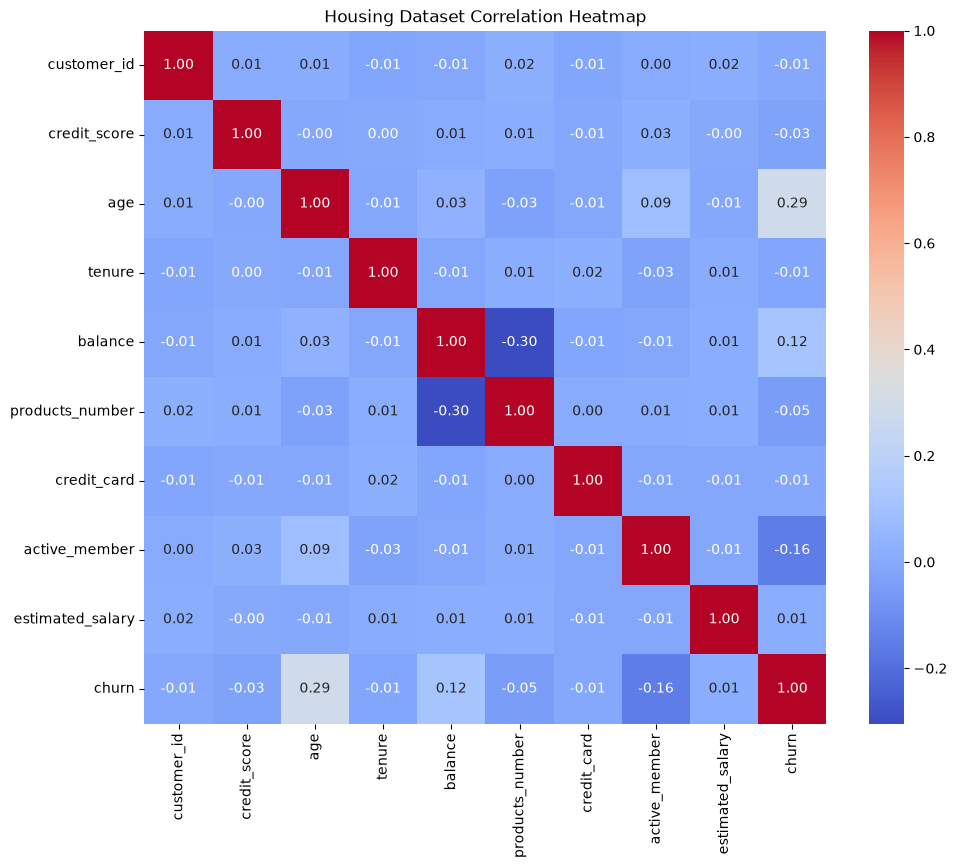

In [10]:
correlation = df.select_dtypes(include='number').corr()
plt.figure(figsize=(11,9))
sns.heatmap(
    correlation,
    annot=True,    #it will show the value inside the correlation map
    cmap='coolwarm',
    
    fmt='.2f'   #used for formatting values 
)
plt.title('Housing Dataset Correlation Heatmap')
plt.show()
